## Preamble

In [2]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [3]:
#c⁻² = εμ ; η² = (cμ)² = μ/ε ==>  
#ε = 1/(ηc) ; μ = η/c
ε0=8.854187817e-6 #*1e-6 F/m or 1 A·µs/(V·m), permittivity of free space
μ0=0.4*np.pi      #*1e-6 H/m or 1 V·µs/(A·m), permeability of free space  

def epsrmur2celimp(epsr,mur):
    eps = epsr*ε0
    mu  = mur *μ0
    cel = (eps*mu)**(-0.5)
    imp = np.sqrt(mu/eps)
    return cel,imp

def celimp2epsrmur(cel,imp):
    eps = 1./(imp*cel)
    mu  = imp/cel
    return eps/ε0, mu/μ0

epsr range: 1.936972368102998 3.510762417186684
mur range: 1.0 1.8125


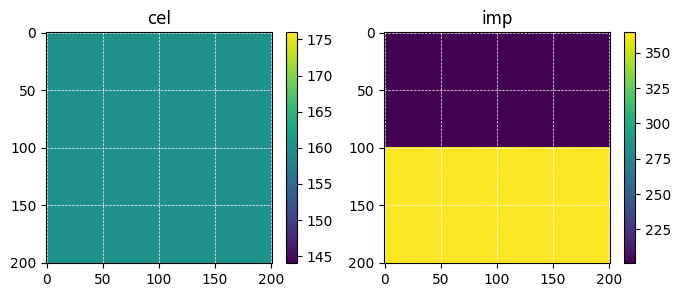

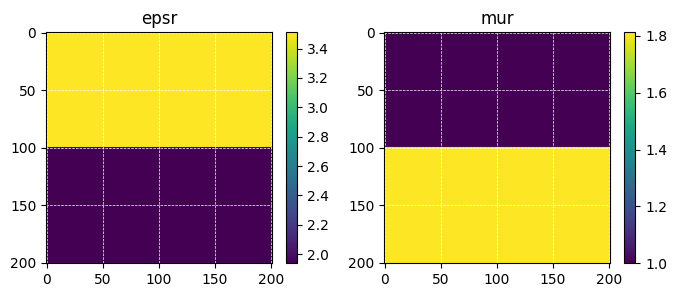

In [28]:
# True
cel=np.ones((nz,nx))
cel[:100,:]=160;  cel[100:,:]=290
mu=0.4*np.pi
imp=cel*mu

cel=160*np.ones((nz,nx))

#plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(cel,title='cel')
plt.subplot(1,2,2); imshow(imp,title='imp')

epsr, mur = celimp2epsrmur(cel, imp)
model=np.concatenate((epsr, mur),axis=1)
model.astype('float32').T.tofile('true')

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(epsr,title='epsr'); print('epsr range:',epsr.min(),epsr.max())
plt.subplot(1,2,2); imshow(mur ,title='mur' ); print('mur range:', mur.min(), mur.max())

epsr range: 1.8230328170381156 3.304246980881585
mur range: 0.9411764705882353 1.7058823529411766
epsr0 range: 3.1098795114179625 3.1098795114179625
mur0 range: 1.0 1.0


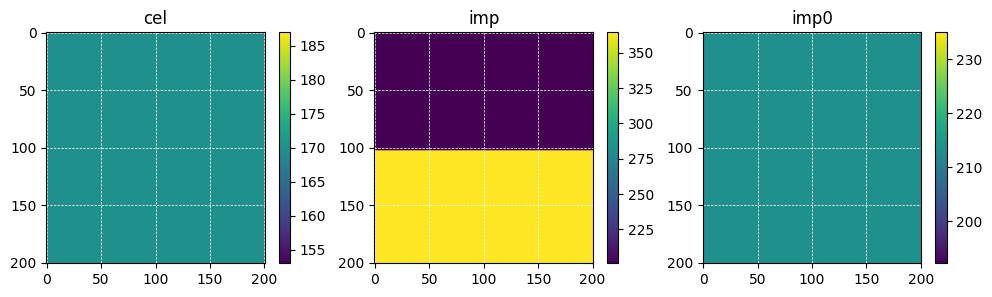

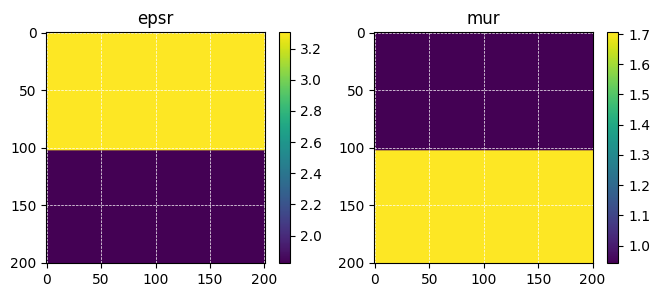

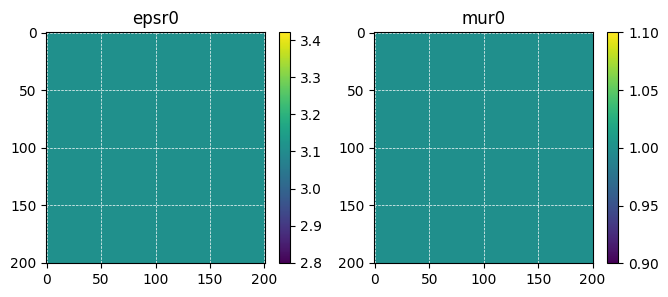

In [29]:
# True impedance
cel=np.ones((nz,nx))
cel[:100,:]=160;  cel[100:,:]=290
imp=cel*mu

## Adjust reflector depth in initial st TWTT is preserved at 0 offset
# TWTT = (99*h-75) / 160 *2  #FS=75
# zref = 170 * (TWTT/2) +75
# izref=int(zref/h); print(izref)
izref=103
imp[:izref,:] = imp[0,   0]
imp[izref:,:] = imp[nz-1,0]

cel=170*np.ones((nz,nx)) #init cel
imp0=cel*mu

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(cel, title='cel')
plt.subplot(1,3,2); imshow(imp, title='imp')
plt.subplot(1,3,3); imshow(imp0,title='imp0')


epsr,  mur  = celimp2epsrmur(cel, imp)
epsr0, mur0 = celimp2epsrmur(cel, imp0)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(epsr,title='epsr'); print('epsr range:',epsr.min(),epsr.max())
plt.subplot(1,3,2); imshow(mur ,title='mur' ); print('mur range:', mur.min(), mur.max())

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(epsr0,title='epsr0'); print('epsr0 range:',epsr0.min(),epsr0.max())
plt.subplot(1,3,2); imshow(mur0 ,title='mur0' ); print('mur0 range:', mur0.min(), mur0.max())

model=np.concatenate((epsr, mur, epsr0, mur0),axis=1)
model.astype('float32').T.tofile('init')

model=np.concatenate((epsr0, mur0),axis=1)
model.astype('float32').T.tofile('bkgr')

In [9]:
#topo
!makevel nz=1   nx=$nx v000=78  > topo

In [10]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '1.5   1.5   1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'epsr mur' # sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   Ey
RCOMP                   Ey #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT                'Ey Hx Hz'


### for inversion ###
FILE_DATA_PREFIX        'results_obs/Ru_Shot'
WEIGHTING               'none'

PARAMETER               'epsr:1.06:3.52'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Writing setup_default


In [11]:
%%writefile fsepa
0    225   #aoffset
0.5 1.68   #time

Writing fsepa


## TE Ey-Ey

### Obs & Syn data

In [12]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest_RWI
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 643648 Jul  9 21:30 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 5365814
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/09/2026
System time: 21:30:50
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) 

In [13]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest_RWI
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 643648 Jul  9 21:30 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 5365814
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/09/2026
System time: 21:30:53
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) 

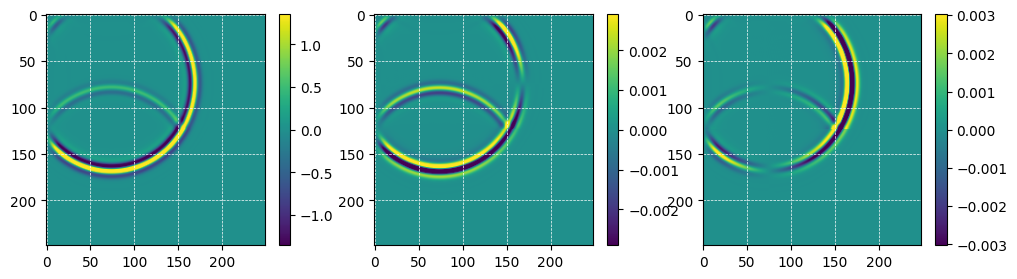

In [14]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%Hz',(51,249,249)),perc=98)

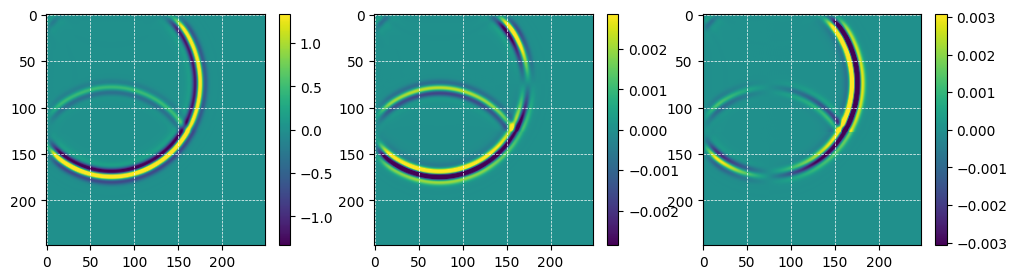

In [15]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%Hz',(51,249,249)),perc=98)

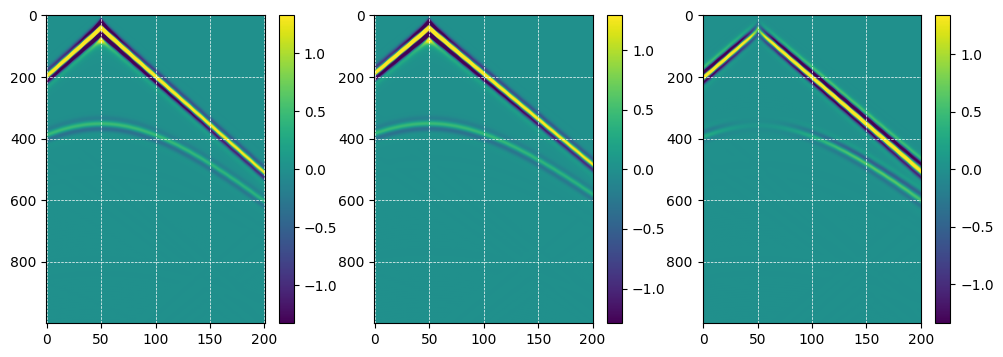

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su') \
                          -read_su('results_syn/Ru_Shot0001.su'),perc=98)

(-5.0, 5.0)

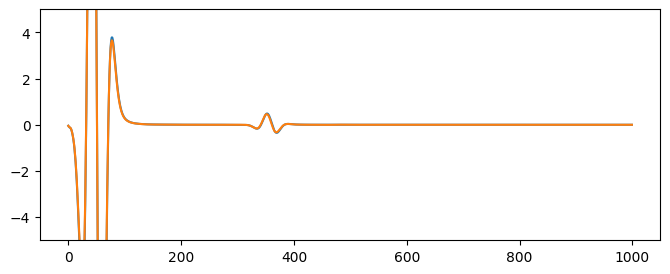

In [17]:
plt.figure(figsize=(8,3))
plt.plot(read_su('results_obs/Ru_Shot0001.su')[:,50])
plt.plot(read_su('results_syn/Ru_Shot0001.su')[:,50])
plt.ylim([-5,5])

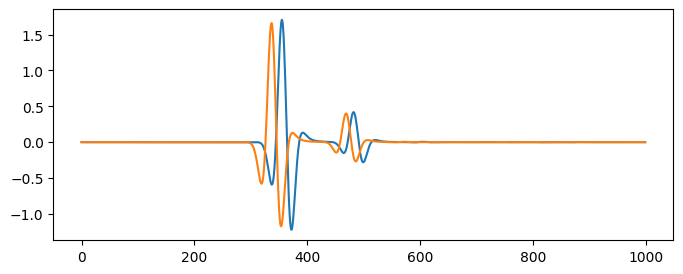

In [18]:
plt.figure(figsize=(8,3))
plt.plot(read_su('results_obs/Ru_Shot0001.su')[:,150])
plt.plot(read_su('results_syn/Ru_Shot0001.su')[:,150])

### Gradient rwi_TE_FDSG_O4_celerity-impedance

#### on gimp

In [6]:
#"PARAMETER   'cel:160:290  mu:1.25663708:1.5'"
print(160*1.25663708 , 290*1.5)

201.0619328 435.0


In [32]:
!cp setup_default setup
!echo "DIR_OUT     'grad_imp'" >> setup
!echo 'FILE_MODEL   bkgr' >> setup
!echo "SEPA                    'aoffset:20 polygon:fsepa d/r:1/5'" >> setup
!echo "PARAMETER   'imp:201:435'" >> setup
!echo "JOB         'build Ip gradient' " >> setup
run(app='../../exe/RWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest_RWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 26 Jul 10 12:53 ../../exe/RWI -> rwi_TE_FDSG_O4_Wolfe_NLCG_
 Git Commit: 63eca57
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/10/2026
System time: 13:51:26
System timezone: +03:00
                        
       WELCOME TO SeisJIMU RWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : grad_imp
 Output directory:grad_imp/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(

 it----         100
 fld_u0 minmax values:  -3.53596139       4.06091118    
 it----         200
 fld_u0 minmax values:  -1.83560848       2.43708682    
 it----         300
 fld_u0 minmax values:  -1.39054978       1.90759456    
 it----         400
 fld_u0 minmax values:  -1.16145158       1.62207282    
 it----         500
 fld_u0 minmax values:  -1.01617622       1.43713617    
 it----         600
 fld_u0 minmax values: -0.878020763       1.30460954    
 it----         700
 fld_u0 minmax values: -0.778442204       1.05382121    
 it----         800
 fld_u0 minmax values:  -1.08749745E-02   6.14632666E-03
 it----         900
 fld_u0 minmax values:  -8.60348344E-03   7.46819936E-03
 it----        1000
 fld_u0 minmax values:  -4.83489502E-03   5.12473984E-03
 Elapsed time to update H      0.121896505    
 Elapsed time to add current density vector   2.81870365E-04
 Elapsed time to update E    0.111737370    
 Elapsed time to extract field         6.76834583E-03
 Elapsed time to save b

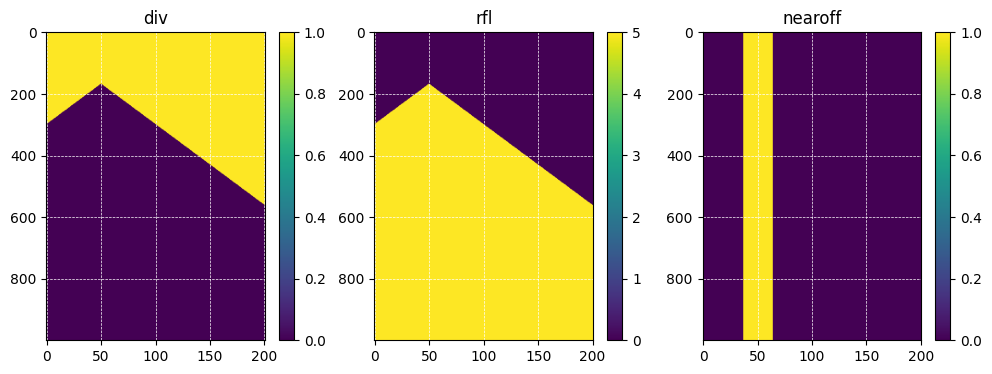

In [33]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('grad_imp/sepa%diving.su')    ,title='div')
plt.subplot(1,3,2); imshow(read_su('grad_imp/sepa%reflection.su'),title='rfl')
plt.subplot(1,3,3); imshow(read_su('grad_imp/sepa%nearoffset.su'),title='nearoff')

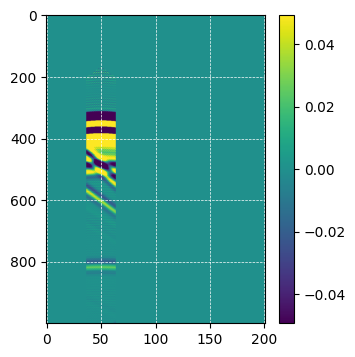

In [34]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('grad_imp/dadj_Shot0001.su'),perc=98)

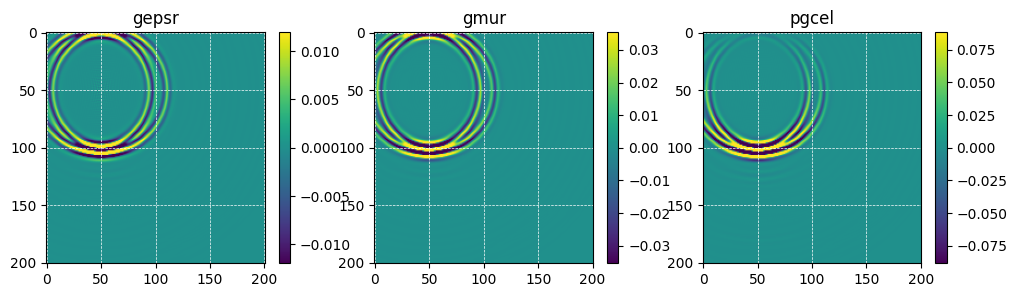

In [35]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('grad_imp/correlate_gradient',(3*nx,nz))[:,nx:2*nx],perc=98,title='gepsr')
plt.subplot(1,3,2); imshow(read('grad_imp/correlate_gradient',(3*nx,nz))[:,:nx],    perc=98,title='gmur')
plt.subplot(1,3,3); imshow(read('grad_imp/qp0%pg'),perc=98,title='pgcel')

#### on gcel

In [6]:
#"PARAMETER   'cel:160:290  mu:1.25663708:1.5'"
print(160*1.25663708 , 290*1.5)

201.0619328 435.0


In [17]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "MODEL_ATTRIBUTES        'epsr mur epsr0 mur0'" >> setup
#!echo "SEPA                    'aoffset:20 polygon:fsepa d/r:1/5'" >> setup
!echo "SEPA                    'aoffset:0 polygon:fsepa d/r:1/5'" >> setup
!echo "PARAMETER   'cel:160:290'" >> setup
!echo "JOB          gradient " >> setup
run(app='../../exe/RWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest_RWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 26 Jul 10 12:53 ../../exe/RWI -> rwi_TE_FDSG_O4_Wolfe_NLCG_
 Git Commit: 63eca57
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 07/10/2026
System time: 12:53:30
System timezone: +03:00
                        
       WELCOME TO SeisJIMU RWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_ce

 it----         100
 fld_u0 minmax values:  -3.53596139       4.06091118    
 it----         200
 fld_u0 minmax values:  -1.83560848       2.43708682    
 it----         300
 fld_u0 minmax values:  -1.39054978       1.90759456    
 it----         400
 fld_u0 minmax values:  -1.16145158       1.62207282    
 it----         500
 fld_u0 minmax values:  -1.01617622       1.43713617    
 it----         600
 fld_u0 minmax values: -0.878020763       1.30460954    
 it----         700
 fld_u0 minmax values: -0.778442204       1.05382121    
 it----         800
 fld_u0 minmax values:  -1.08749745E-02   6.14632666E-03
 it----         900
 fld_u0 minmax values:  -8.60348344E-03   7.46819936E-03
 it----        1000
 fld_u0 minmax values:  -4.83489502E-03   5.12473984E-03
 Elapsed time to update H      0.121896505    
 Elapsed time to add current density vector   2.81870365E-04
 Elapsed time to update E    0.111737370    
 Elapsed time to extract field         6.76834583E-03
 Elapsed time to save b

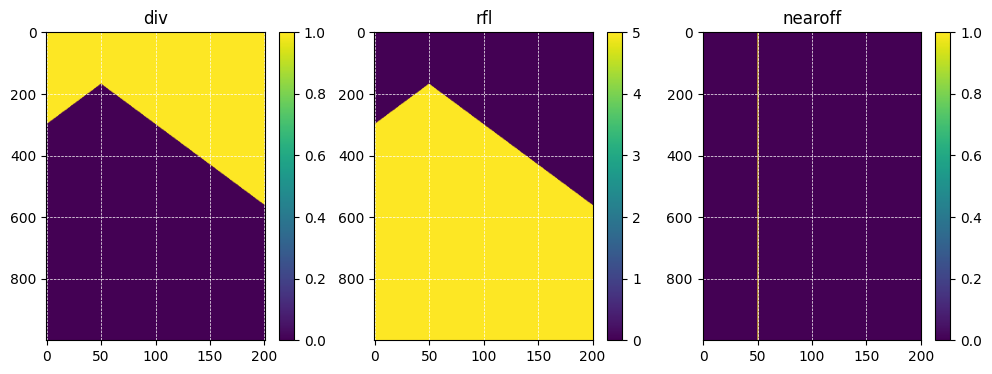

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results/sepa%diving.su')    ,title='div')
plt.subplot(1,3,2); imshow(read_su('results/sepa%reflection.su'),title='rfl')
plt.subplot(1,3,3); imshow(read_su('results/sepa%nearoffset.su'),title='nearoff')

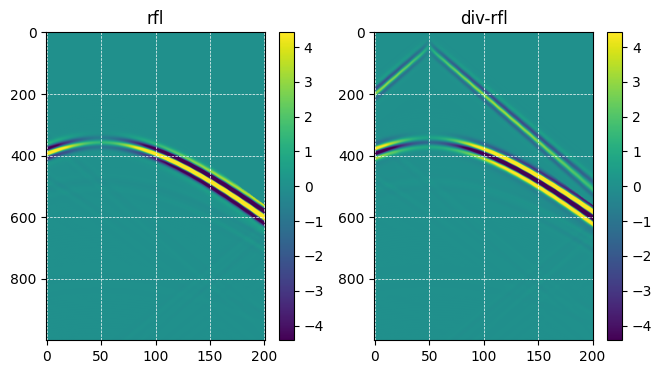

In [21]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results/dadj_refl_Shot0001.su')    ,perc=98,title='rfl')
plt.subplot(1,3,2); imshow(read_su('results/dadj_div-refl_Shot0001.su'),perc=98,title='div-rfl')

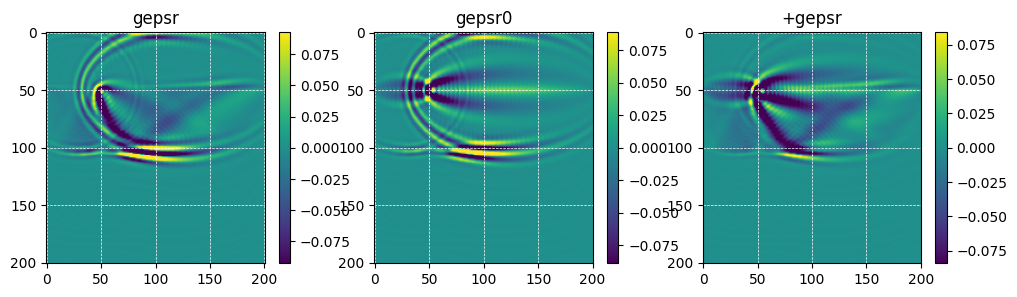

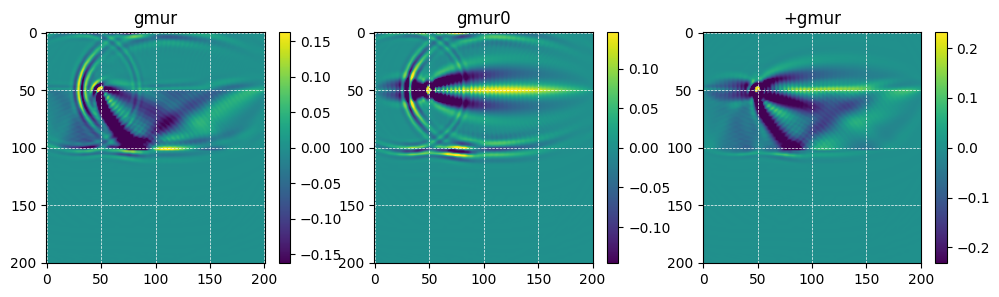

In [19]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/gepsr_Shot0001'),  perc=98,title='gepsr')
plt.subplot(1,3,2); imshow(read('results/g0epsr_Shot0001'), perc=98,title='gepsr0')
plt.subplot(1,3,3); imshow(read('results/correlate_gradient',(3*nx,nz))[:,nx:2*nx],perc=98,title='+gepsr')

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/gmur_Shot0001'),   perc=98,title='gmur')
plt.subplot(1,3,2); imshow(read('results/g0mur_Shot0001'),  perc=98,title='gmur0')
plt.subplot(1,3,3); imshow(read('results/correlate_gradient',(3*nx,nz))[:,:nx], perc=98,title='+gmur')

In [20]:
#c⁻² = (ε₀μ₀)εᵣμᵣ ; η² = (μ₀/ε₀)μᵣ/εᵣ ==>  
#εᵣ = ε₀⁻¹η⁻¹c⁻¹ ; μᵣ = μ₀⁻¹ηc⁻¹
#So,
#gcel = gepsr ∂εᵣ/∂c + gmur ∂μᵣ/∂c = gepsr (-1)ε₀⁻¹η⁻¹c⁻² + gmur (-1)μ₀⁻¹ηc⁻²
#     =-( (gepsr/ε₀)/η + (gmur/μ₀)η )c⁻²
#gimp = gepsr ∂εᵣ/∂η + gmur ∂μᵣ/∂η = gepsr (-1)ε₀⁻¹η⁻²c⁻¹ + gmur μ₀⁻¹c⁻¹
#     = (-(gepsr/ε₀)/η² + gmur/μ₀ )c⁻¹
def gepsrmur2gcelimp(gepsr, gmur, epsr, mur):
    c = (ε0*μ0*epsr*mur)**(-0.5)
    η = np.sqrt((μ0/ε0)*mur/epsr)
    gcel =-( (gepsr/ε0)/η   + (gmur/μ0)*η )/c/c
    gimp = (-(gepsr/ε0)/η/η +  gmur/μ0    )/c
    return gcel, gimp

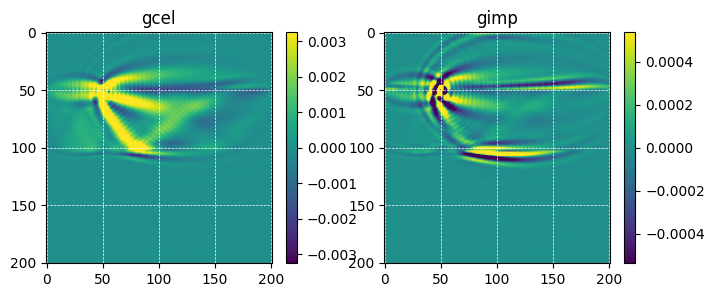

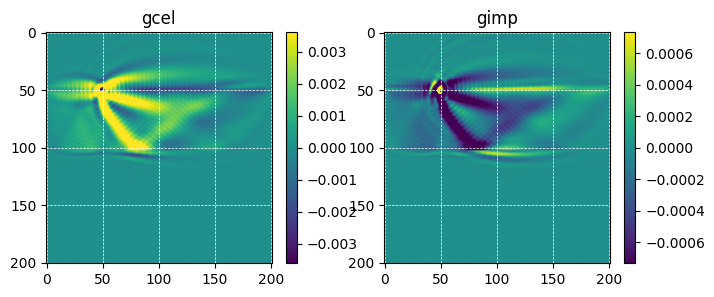

In [21]:
gepsr = read('results/correlate_gradient',(3*nx,nz))[:,nx:2*nx]
gmur  = read('results/correlate_gradient',(3*nx,nz))[:,:nx]

gcel,gimp = gepsrmur2gcelimp(gepsr, gmur, epsr[0,0], mur[0,0])
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(gcel,perc=98,title='gcel')
plt.subplot(1,2,2); imshow(gimp,perc=98,title='gimp')

gcel,gimp = gepsrmur2gcelimp(gepsr, gmur, epsr[nz-1,0], mur[nz-1,0])
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(gcel,perc=98,title='gcel')
plt.subplot(1,2,2); imshow(gimp,perc=98,title='gimp')

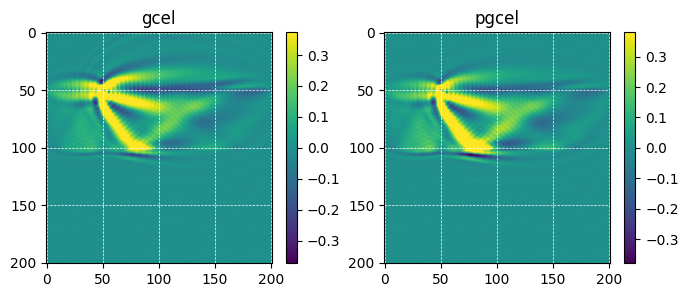

In [22]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results/qp0%g' ),perc=98,title='gcel')
plt.subplot(1,2,2); imshow(read('results/qp0%pg'),perc=98,title='pgcel')

### gradienttest_RWI_TE_FDSG_O4

#### on gimp

In [36]:
!cp setup_default setup
!echo 'FILE_MODEL   bkgr' >> setup
!echo "SEPA                    'aoffset:20 polygon:fsepa d/r:1/5'" >> setup
!echo "PARAMETER   'imp:201:435'" >> setup
!echo "JOB         'build Ip linesearch' " >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   1.84976864       1.84992301      -15.4376030      -15.7636518       1.02112043     T
 1st cond   9.99999975E-05   1.84839427       1.84992301      -15.2873993      -15.7636518       1.03115332     T
 1st cond   1.00000005E-03   1.83465350       1.84992301      -15.2695169      -15.7636518       1.03236091     T
 1st cond   9.99999978E-03   1.70086098       1.84992301      -14.9062042      -15.7636518       1.05752289     T
 1st cond  0.100000001      0.722820520       1.84992301      -11.2710247      -15.7636518       1.39859974     T
 1st cond   1.00000000       7.86036348       1.84992301       6.01044035      -15.7636518      -2.62271166     F


#### on gcel

In [25]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "MODEL_ATTRIBUTES        'epsr mur epsr0 mur0'" >> setup
#!echo "SEPA                    'aoffset:20 polygon:fsepa d/r:1/5'" >> setup
!echo "SEPA                    'aoffset:0 polygon:fsepa d/r:1/5'" >> setup
!echo "PARAMETER   'cel:160:290'" >> setup
!echo "JOB          linesearch " >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   10.4033833       10.4035378      -15.4495239      -15.8402424       1.02529001     T
 1st cond   9.99999975E-05   10.4019947       10.4035378      -15.4304504      -15.8402424       1.02655733     T
 1st cond   1.00000005E-03   10.3881168       10.4035378      -15.4209127      -15.8402424       1.02719223     T
 1st cond   9.99999978E-03   10.2498674       10.4035378      -15.3670311      -15.8402424       1.03079391     T
 1st cond  0.100000001       8.94039249       10.4035378      -14.6314526      -15.8402424       1.08261585     T
 1st cond   1.00000000       7.04479265       10.4035378      -3.35874510      -15.8402424       4.71611929     T


In [26]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "MODEL_ATTRIBUTES        'epsr mur epsr0 mur0'" >> setup
#!echo "SEPA                    'aoffset:20 polygon:fsepa d/r:1/5'" >> setup
!echo "SEPA                    'aoffset:0 polygon:fsepa d/r:1/5'" >> setup
!echo "PARAMETER   'cel:160:290'" >> setup
!echo "JOB          linesearch " >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_celerity-impedance  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   10.4036894       10.4035378      -15.1634216      -15.8402424       1.04463506     F
 1st cond  -9.99999975E-05   10.4050751       10.4035378      -15.3732300      -15.8402424       1.03037834     F
 1st cond  -1.00000005E-03   10.4189701       10.4035378      -15.4323568      -15.8402424       1.02643049     F
 1st cond  -9.99999978E-03   10.5584660       10.4035378      -15.4928207      -15.8402424       1.02242470     F
 1st cond -0.100000001       11.9921846       10.4035378      -15.8864689      -15.8402424      0.997090220     F
 1st cond  -1.00000000       22.5073051       10.4035378      -12.1037674      -15.8402424       1.30870342     F
